Importing Libraries and Setting Up the Environment

In [1]:
import numpy as np
import pandas as pd 

import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


Collecting Historical Gold Price Data

In [2]:
stocks = input("Enter the code of the stock:- ")
# Download historical Gold Futures data
data = yf.download(
    stocks,
    "2010-01-01",
    "2026-01-01",
    auto_adjust=True
)

data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2010-01-04,0.423290,0.426267,0.414591,0.423748,800204000
2010-01-05,0.429472,0.434050,0.421688,0.421688,728648000
2010-01-06,0.432219,0.433134,0.425122,0.429243,649168000
2010-01-07,0.423748,0.431761,0.420543,0.429929,547792000
2010-01-08,0.424664,0.427640,0.417796,0.420314,478168000


In [3]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NVDA)   4024 non-null   float64
 1   (High, NVDA)    4024 non-null   float64
 2   (Low, NVDA)     4024 non-null   float64
 3   (Open, NVDA)    4024 non-null   float64
 4   (Volume, NVDA)  4024 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB


In [4]:
data.shape

(4024, 5)

In [5]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
count,4024.000000,4024.000000,4024.000000,4024.000000,4.024000e+03
mean,22.639561,23.021695,22.216602,22.642367,4.798230e+08
std,43.938953,44.636558,43.174773,43.970637,3.051001e+08
min,0.203289,0.207181,0.198024,0.199626,4.564400e+07
25%,0.429077,0.435471,0.423013,0.429648,2.859258e+08
50%,3.974096,4.055971,3.909704,3.977092,4.103275e+08
75%,17.520878,17.874429,16.946594,17.454005,5.861402e+08
max,206.776276,211.919725,205.298145,207.814939,3.692928e+09


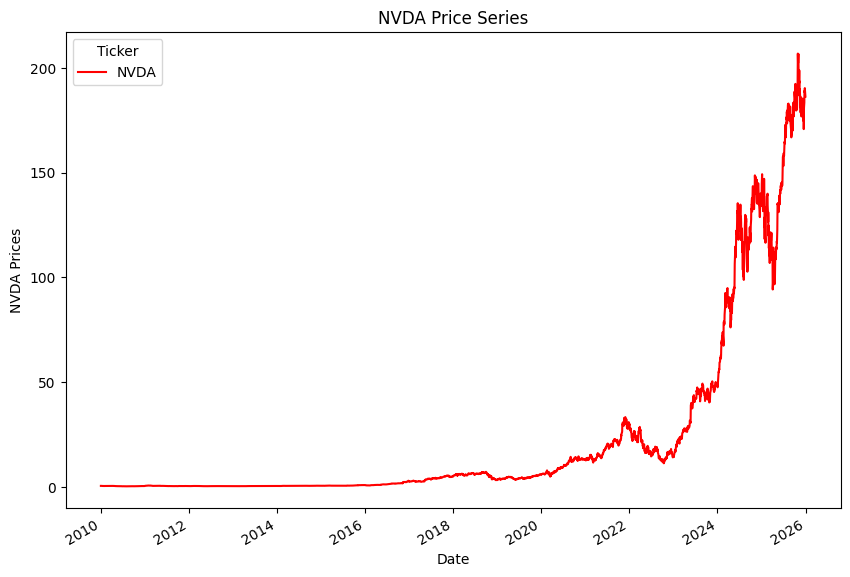

In [6]:
data.Close.plot(figsize=(10, 7), color='r')
plt.ylabel("{} Prices".format(stocks))
plt.title("{} Price Series".format(stocks))
plt.show()


<Axes: ylabel='Count'>

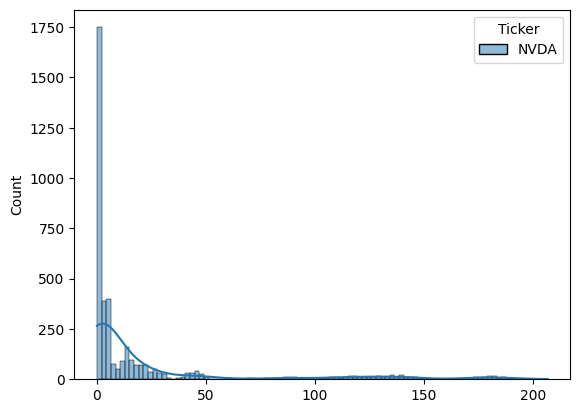

In [7]:
sns.histplot(data["Close"], kde=True)


<Axes: ylabel='Count'>

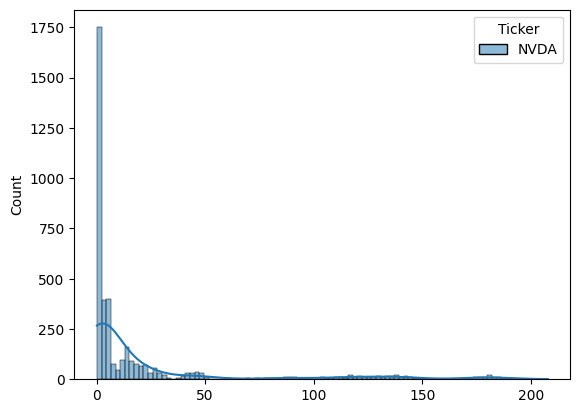

In [8]:
sns.histplot(data["Open"], kde=True)


<Axes: ylabel='Count'>

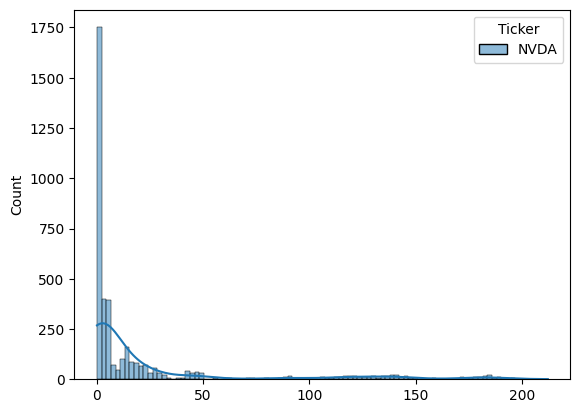

In [9]:
sns.histplot(data["High"], kde=True)

In [10]:
x = data.drop("Close" , axis = 1)
y = data["Close"]

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3219, 4)
(805, 4)
(3219, 1)
(805, 1)


In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)
pred1 = lr.predict(x_test)


In [12]:
pred1

array([[ 2.81868614e+01],
       [ 1.29130567e+01],
       [ 2.23043854e+01],
       [ 2.41708327e+01],
       [ 4.63952737e+00],
       [ 2.19593244e+01],
       [ 1.41963720e+01],
       [ 2.15456763e+01],
       [ 1.28382344e+01],
       [ 2.15048287e+01],
       [ 2.98143875e+01],
       [ 1.55151500e+01],
       [ 1.02713204e+01],
       [ 2.47587118e+01],
       [ 3.13086046e+01],
       [-7.46425041e+00],
       [ 2.86002261e+01],
       [ 3.01826888e+01],
       [ 2.87070746e+01],
       [ 2.80883738e+01],
       [ 1.60557338e+01],
       [ 2.52473948e+01],
       [ 9.81785207e+00],
       [ 3.35612615e+01],
       [ 1.53886748e+01],
       [ 2.51992138e+01],
       [ 2.14199805e+01],
       [ 2.17562556e+01],
       [ 2.78366988e+01],
       [ 2.95489668e+01],
       [ 1.64158869e+01],
       [ 3.12686037e+01],
       [ 2.63535740e+01],
       [ 1.43012366e+01],
       [ 2.84967786e+01],
       [ 1.50957981e+01],
       [ 2.57459619e+01],
       [ 2.55160748e+01],
       [ 3.3

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

def calculate_metrics(y_test, y_pred):
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_scors = r2_score(y_test, y_pred)

    print("MSE:- ", mse)
    print("RMSE:- ", rmse)
    print("R2_score:- ", r2_scors)

calculate_metrics(y_test, pred1)


MSE:-  1916.038745175898
RMSE:-  43.77257983230938
R2_score:-  0.08285886762415784


In [14]:
from sklearn.linear_model import Lasso , Ridge

la = Lasso().fit(x_train , y_train)
ri = Ridge().fit(x_train , y_train)

la_p = la.predict(x_test)
ri_p = ri.predict(x_test)


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.543678e+02, tolerance: 6.084e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.658061523288567e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [15]:
calculate_metrics(y_test , la_p)

MSE:-  0.5618586942508195
RMSE:-  0.749572340905679
R2_score:-  0.9997310577772095


In [16]:
calculate_metrics(y_test ,ri_p)

MSE:-  0.21972002073402036
RMSE:-  0.4687430220643507
R2_score:-  0.999894827665083


In [17]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr = SVR()
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(svr, param_grid, refit=True, verbose=3)
grid.fit(x_train , y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.196 total time=   0.1s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.170 total time=   0.1s


...

[CV 4/5] END .C=1000, gamma=0.0001, kernel=rbf;, score=-0.000 total time=   0.3s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 5/5] END .C=1000, gamma=0.0001, kernel=rbf;, score=-0.002 total time=   0.2s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is u

In [18]:
svr = SVR(C=1000, gamma=0.0001, kernel='rbf') 

svr.fit(x_train, y_train)

svr_pred = svr.predict(x_test)

c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [19]:
calculate_metrics(y_test, svr_pred)

MSE:-  2086.8772012950694
RMSE:-  45.68235109202535
R2_score:-  0.001084438222369366


In [20]:
import joblib

joblib.dump(ri, "nvidia_model.pkl")

ridge_from_joblib = model = joblib.load("nvidia_model.pkl")

In [21]:
model = joblib.load("nvidia_model.pkl")

In [22]:
prediction = model.predict(x_test)

print(prediction[:5])

[0.81545632 7.38472616 0.33307998 4.45424767 0.33552711]


In [23]:
print("Predicted:", prediction[:5])
print("Actual:   ", y_test[:5].values)

Predicted: [0.81545632 7.38472616 0.33307998 4.45424767 0.33552711]
Actual:    [[0.81761771]
 [7.33018303]
 [0.33178848]
 [4.46310234]
 [0.33332112]]
